
# Optymalizacja trasy drona w uproszczonym modelu miasta

## Opis problemu rzeczywistego
Rozważamy problem planowania trasy **drona autonomicznego** poruszającego się w przestrzeni miejskiej.
Miasto jest modelowane jako zbiór prostopadłościennych budynków (przeszkód), a zadaniem drona jest
znalezienie **najkrótszej bezkolizyjnej trasy** pomiędzy punktem startowym i końcowym.

Do wyznaczania trasy wykorzystujemy **algorytm oparty na grafie wierzchołków przeszkód**.


In [2]:

from Shape3D import Block, spaceEnum
from VertexRoute import find_vertex_route
import matplotlib.pyplot as plt



## Definicja pola testowego – model miasta

Tworzymy przestrzeń powietrzną oraz zestaw budynków o różnych rozmiarach,
rozmieszczonych na planie miasta.


In [54]:
# Granice przestrzeni (obszar lotu drona)
space_block = Block([0, 0, 0], 120, 120, 60)
space_high = Block([0, 0, 0], 120, 120, 100)
# test 1
# Budynki (prostopadłościany) 
buildings = [
    Block([-30, -30, 0], 20, 20, 40),
    Block([0, -30, 0], 20, 20, 50),
    Block([30, -30, 0], 20, 20, 35),
    Block([-30, 0, 0], 20, 20, 45),
    Block([0, 0, 0], 25, 25, 55),
    #Block([30, 0, 0], 20, 20, 40),
    #Block([-30, 30, 0], 20, 20, 30),
    #Block([0, 30, 0], 20, 20, 45),
    #Block([30, 30, 0], 20, 20, 35),
]

space = {
    spaceEnum.SPACE_LIMITS: space_block,
    spaceEnum.OBJECTS: buildings
}

#test 2
buildings2 = [
    Block([-30, -30, 0], 20, 20, 40),
    #Block([0, -30, 0], 20, 20, 50),
    #Block([30, -30, 0], 20, 20, 35),
    #Block([-30, 0, 0], 20, 20, 45),
    #Block([0, 0, 0], 25, 25, 55),
    Block([30, 0, 0], 20, 20, 40),
    Block([-30, 30, 0], 20, 20, 30),
    Block([0, 30, 0], 20, 20, 45),
    Block([30, 30, 0], 20, 20, 35),
]

space2 = {
    spaceEnum.SPACE_LIMITS: space_block,
    spaceEnum.OBJECTS: buildings2
}

#test 3
buildings3 = [
    Block([-30, -30, 0], 20, 20, 40),
    #Block([0, -30, 0], 20, 20, 50),
    Block([30, -30, 0], 20, 20, 35),
    #Block([-30, 0, 0], 20, 20, 45),
    Block([0, 0, 0], 25, 25, 55),
    #Block([30, 0, 0], 20, 20, 40),
    Block([-30, 30, 0], 20, 20, 30),
    #Block([0, 30, 0], 20, 20, 45),
    Block([30, 30, 0], 20, 20, 35),
]

space3 = {
    spaceEnum.SPACE_LIMITS: space_block,
    spaceEnum.OBJECTS: buildings3
}

#testy 4-6 : inne miejsce docelowe
#test 4 
buildings4 = [
    Block([-30, -30, 0], 20, 20, 40),
    Block([0, -30, 0], 20, 20, 50),
    Block([30, -30, 0], 20, 20, 35),
    Block([-30, 0, 0], 20, 20, 45),
    Block([0, 0, 0], 25, 25, 55),
    #Block([30, 0, 0], 20, 20, 40),
    #Block([-30, 30, 0], 20, 20, 30),
    #Block([0, 30, 0], 20, 20, 45),
    #Block([30, 30, 0], 20, 20, 35),
]

space4 = {
    spaceEnum.SPACE_LIMITS: space_block,
    spaceEnum.OBJECTS: buildings4
}

#test 5
buildings5 = [
    Block([-30, -30, 0], 20, 20, 40),
    Block([0, -30, 0], 20, 20, 50),
    Block([30, -30, 0], 20, 20, 35),
    Block([-30, 0, 0], 20, 20, 45),
    Block([0, 0, 0], 25, 25, 55),
    Block([30, 0, 0], 20, 20, 40),
    Block([-30, 30, 0], 20, 20, 30),
    Block([0, 30, 0], 20, 20, 45),
    Block([30, 30, 0], 20, 20, 35),
]

space5 = {
    spaceEnum.SPACE_LIMITS: space_block,
    spaceEnum.OBJECTS: buildings5
}


#test 6
buildings6 = [
    Block([-30, -30, 0], 20, 20, 40),
    Block([0, -30, 0], 20, 20, 50),
    Block([30, -30, 0], 20, 20, 35),
    Block([-30, 0, 0], 20, 20, 45),
    Block([0, 0, 0], 25, 25, 55),
    Block([30, 0, 0], 20, 20, 40),
    Block([-30, 30, 0], 20, 20, 30),
    Block([0, 30, 0], 20, 20, 45),
    Block([30, 30, 0], 20, 20, 35),
]
space6 = {
    spaceEnum.SPACE_LIMITS: space_block,
    spaceEnum.OBJECTS: buildings6
}

#test 7
buildings7 = [
    Block([-30, -30, 0], 20, 20, 40),
    Block([0, -30, 0], 20, 20, 50),
    Block([30, -30, 0], 20, 20, 35),
    Block([-30, 0, 0], 20, 20, 45),

    # Centralny budynek – dominanta wysokościowa
    Block([0, 0, 0], 25, 25, 80),

    Block([30, 0, 0], 20, 20, 40),
    Block([-30, 30, 0], 20, 20, 30),
    Block([0, 30, 0], 20, 20, 45),
    Block([30, 30, 0], 20, 20, 35),
]
space7 = {
    spaceEnum.SPACE_LIMITS: space_high,
    spaceEnum.OBJECTS: buildings7
}


## Wyznaczanie trasy drona

Dron startuje z jednego krańca miasta i musi dotrzeć do punktu docelowego,
omijając wszystkie przeszkody.


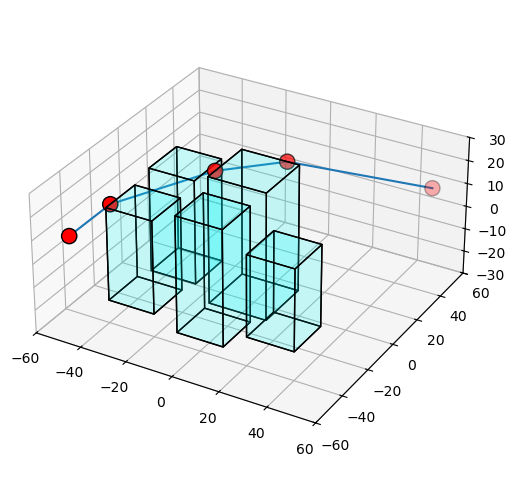

{'path': [(np.int64(-50), np.int64(-50), np.int64(10)),
  (np.float64(-40.0), np.float64(-36.99399627714862), np.float64(20.0)),
  (np.float64(-12.5), np.float64(-7.239493485010079), np.float64(27.5)),
  (np.float64(7.239493485010078), np.float64(12.5), np.float64(27.5)),
  (np.int64(50), np.int64(50), np.int64(10))],
 'length': np.float64(147.84000748838537)}

In [ ]:
start = [-50, -50, 10]
end = [50, 50, 10]

find_vertex_route(space, start, end)


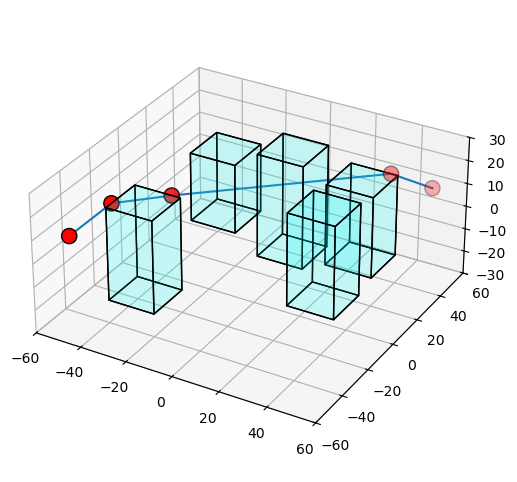

{'path': [(np.int64(-50), np.int64(-50), np.int64(10)),
  (np.float64(-40.0), np.float64(-36.21062618036988), np.float64(20.0)),
  (np.float64(-23.78937381963012), np.float64(-20.0), np.float64(20.0)),
  (np.float64(37.15796963527741), np.float64(40.0), np.float64(17.5)),
  (np.int64(50), np.int64(50), np.int64(10))],
 'length': np.float64(146.16041698723)}

In [8]:
start = [-50, -50, 10]
end = [50, 50, 10]

find_vertex_route(space2, start, end)

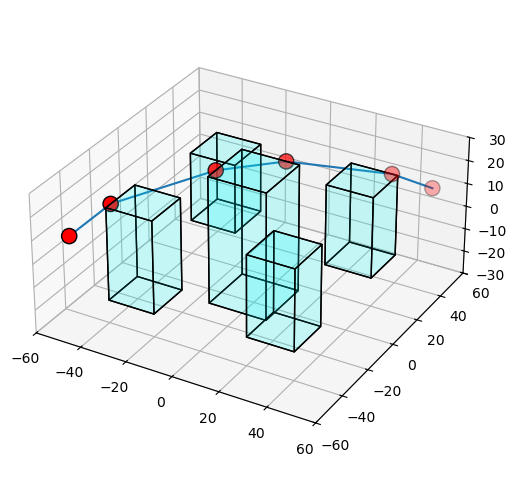

{'path': [(np.int64(-50), np.int64(-50), np.int64(10)),
  (np.float64(-40.0), np.float64(-36.73503072989685), np.float64(20.0)),
  (np.float64(-12.5), np.float64(-6.786303777319482), np.float64(27.5)),
  (np.float64(6.786303777319484), np.float64(12.5), np.float64(27.5)),
  (np.float64(37.55127304742263), np.float64(40.0), np.float64(17.5)),
  (np.int64(50), np.int64(50), np.int64(10))],
 'length': np.float64(148.10989195913007)}

In [11]:
start = [-50, -50, 10]
end = [50, 50, 10]

find_vertex_route(space3, start, end)

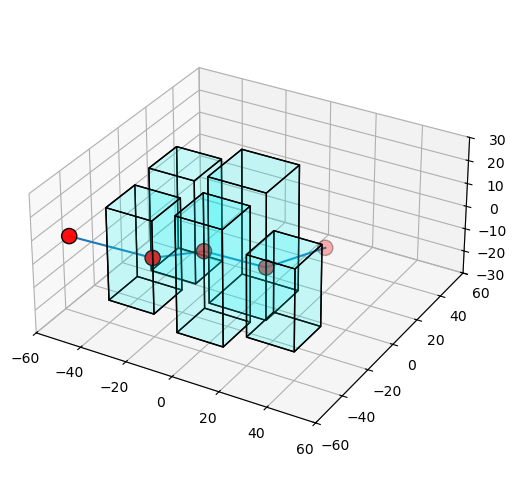

{'path': [(np.int64(-50), np.int64(-50), np.int64(10)),
  (np.float64(-20.0), np.float64(-40.0), np.float64(4.336412896416321)),
  (np.float64(-10.0), np.float64(-20.0), np.float64(0.02534930535101798)),
  (np.float64(12.5), np.float64(-12.5), np.float64(-4.222341022336742)),
  (np.int64(20), np.int64(20), np.int64(-10))],
 'length': np.float64(112.84373691001497)}

In [5]:
start4 = [-50, -50, 10]
end4 = [20, 20, -10]

find_vertex_route(space4, start4, end4)

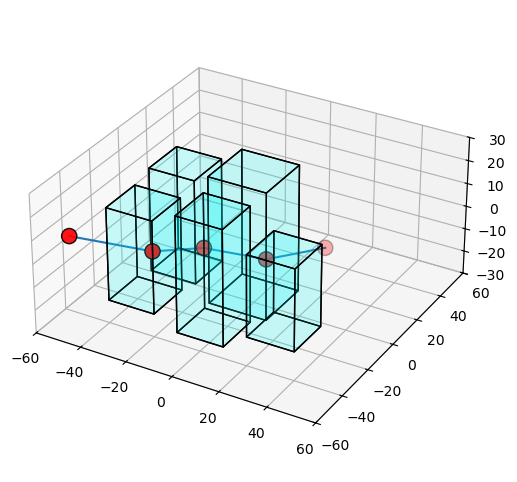

{'path': [(np.int64(-50), np.int64(-50), np.int64(10)),
  (np.float64(-20.0), np.float64(-40.0), np.float64(7.1428571428571415)),
  (np.float64(-10.0), np.float64(-20.0), np.float64(1.4285714285714277)),
  (np.float64(12.5), np.float64(-12.5), np.float64(-0.7142857142857157)),
  (np.int64(20), np.int64(20), np.int64(-10))],
 'length': np.float64(113.26715552465765)}

In [ ]:
#ponownie test 4, teraz jednak z mniejszą ilością sprawdzanych płaszczyzn (nazwę to test 4a najwyżej)
start4 = [-50, -50, 10]
end4 = [20, 20, -10]

find_vertex_route(space4, start4, end4,combine_planes = False, number_of_planes = 6)

#ile razy zmniejszymy ilość sprawdzanych płaszczyzn, tyle razy szybciej (w przybliżeniu) otrzymamy wynik

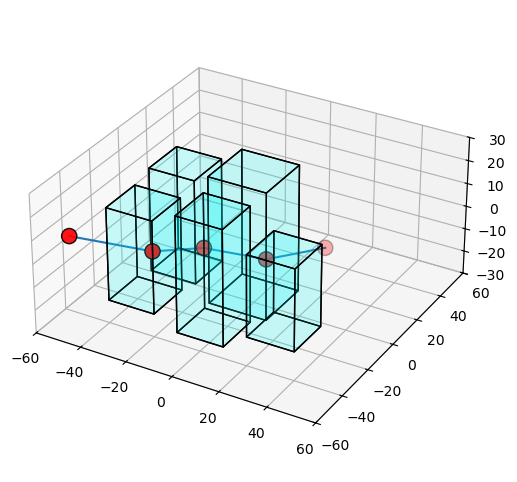

{'path': [(np.int64(-50), np.int64(-50), np.int64(10)),
  (np.float64(-20.0), np.float64(-40.0), np.float64(7.1428571428571415)),
  (np.float64(-10.0), np.float64(-20.0), np.float64(1.4285714285714277)),
  (np.float64(12.5), np.float64(-12.5), np.float64(-0.7142857142857157)),
  (np.int64(20), np.int64(20), np.int64(-10))],
 'length': np.float64(113.26715552465765)}

In [ ]:
#jeszcze jeden test4b, ale ze zbieraniem informacji z wielu płaszczyzn
start4 = [-50, -50, 10]

end4 = [20, 20, -10]

find_vertex_route(space4, start4, end4,combine_planes = True, number_of_planes = 6)

#czas wydłużył się około 2n razy, gdzie n to liczba płaszczyzn

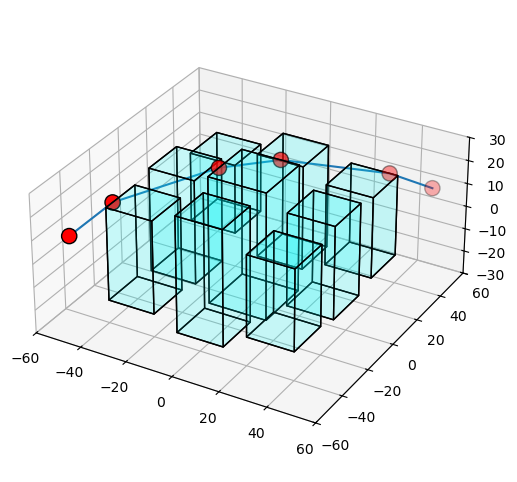

{'path': [(np.int64(-50), np.int64(-50), np.int64(10)),
  (np.float64(-40.0), np.float64(-35.404941589052775), np.float64(20.0)),
  (np.float64(-12.5), np.float64(-4.458647780842359), np.float64(27.5)),
  (np.float64(4.458647780842359), np.float64(12.5), np.float64(27.5)),
  (np.float64(36.55370619178959), np.float64(40.0), np.float64(17.5)),
  (np.int64(50), np.int64(50), np.int64(10))],
 'length': np.float64(148.17040928417325)}

In [ ]:
#pełna zabudowa, gęsto upakowane
start5 = [-50, -50, 10]
end5 = [50, 50, 10]

find_vertex_route(space5, start5, end5,combine_planes = False, number_of_planes = 10)

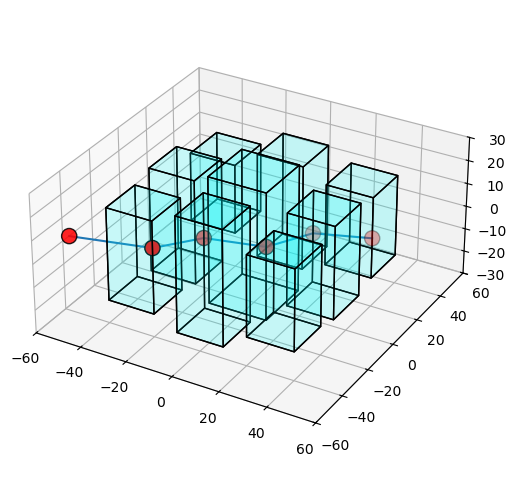

{'path': [(np.int64(-50), np.int64(-50), np.int64(10)),
  (np.float64(-20.0), np.float64(-40.0), np.float64(8.57142857142857)),
  (np.float64(-10.0), np.float64(-20.0), np.float64(5.714285714285714)),
  (np.float64(12.5), np.float64(-12.5), np.float64(4.642857142857142)),
  (np.float64(20.0), np.float64(10.0), np.float64(1.4285714285714293)),
  (np.int64(40), np.int64(20), np.int64(0))],
 'length': np.float64(124.27894509709246)}

In [ ]:
#test 6, pełna zabudowa gęsto upakowane, inny docelowy punkt
start6 = [-50, -50, 10]
end6 = [40, 20, 0]

find_vertex_route(space6, start6, end6,combine_planes = False, number_of_planes = 10)

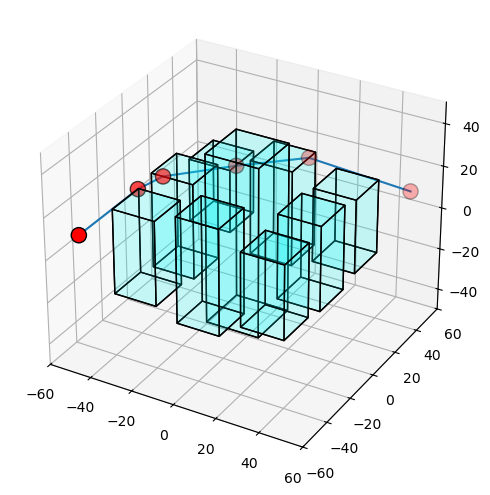

{'path': [(np.int64(-50), np.int64(-50), np.int64(10)),
  (np.float64(-40.0), np.float64(-20.535020210645403), np.float64(20.0)),
  (np.float64(-34.33122473669325), np.float64(-10.0), np.float64(22.5)),
  (np.float64(-12.5), np.float64(12.5), np.float64(22.843578709325197)),
  (np.float64(10.0), np.float64(34.33122473669325), np.float64(22.5)),
  (np.int64(50), np.int64(50), np.int64(10))],
 'length': np.float64(152.35062677678246)}

In [55]:
#pełna zabudowa, gęsto upakowane
start7 = [-50, -50, 10]
end7 = [50, 50, 10]

find_vertex_route(space7, start7, end7,combine_planes = False, number_of_planes = 10)


## Wnioski

- Problem planowania trasy drona można skutecznie sprowadzić do problemu optymalizacji grafowej.
- Przeszkody w postaci budynków generują wierzchołki ograniczające przestrzeń rozwiązań.
- Algorytm wyznacza trasę bezkolizyjną bez potrzeby dyskretyzacji przestrzeni na siatkę.
